The dataset has no missing variables that need to be handled. As discussed in the EDA, the follower-related features in the dataset - `edge_followed_by` and `edge_follow` - have strong right skews and contain extreme outliers.

To determine the best transformation to use on each feature, we use the Yeo-Johnson transformation, which evaluates various power transformations and estimates the optimal transformation parameter through maximum likelihood.

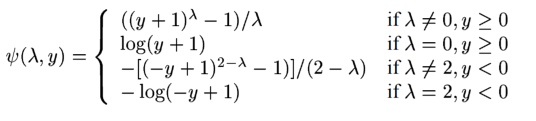

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
import seaborn as sns

In [2]:
path = kagglehub.dataset_download("rezaunderfit/instagram-fake-and-real-accounts-dataset")

print("Dataset downloaded to:", path)

# List files in the folder
print("Files inside dataset folder:")
print(os.listdir(path))

Dataset downloaded to: C:\Users\megan\.cache\kagglehub\datasets\rezaunderfit\instagram-fake-and-real-accounts-dataset\versions\1
Files inside dataset folder:
['final-v1.csv']


In [3]:
file_path = os.path.join(path, "final-v1.csv")

df = pd.read_csv(file_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edge_followed_by      785 non-null    float64
 1   edge_follow           785 non-null    float64
 2   username_length       785 non-null    int64  
 3   username_has_number   785 non-null    int64  
 4   full_name_has_number  785 non-null    int64  
 5   full_name_length      785 non-null    int64  
 6   is_private            785 non-null    int64  
 7   is_joined_recently    785 non-null    int64  
 8   has_channel           785 non-null    int64  
 9   is_business_account   785 non-null    int64  
 10  has_guides            785 non-null    int64  
 11  has_external_url      785 non-null    int64  
 12  is_fake               785 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 79.9 KB


In [4]:
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.model_selection import train_test_split

num_features = ['edge_followed_by', 'edge_follow', 'username_length', 'full_name_length']
cat_features = [col for col in df.columns if col not in num_features]
target = 'is_fake'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
X_cols = X_train.columns

tf = YeoJohnsonTransformer(variables = num_features)

tf.fit(X_train)

X_train_tf = tf.transform(X_train)
X_test_tf = tf.transform(X_test)

tf.lambda_dict_

{'edge_followed_by': np.float64(-110.42006816830508),
 'edge_follow': np.float64(-0.9101106571160141),
 'username_length': np.float64(-0.3031245373872942),
 'full_name_length': np.float64(0.02586706117862299)}

The applied transforms for each numerical variable are:
* `edge_followed_by`: $\frac{((x+1)^{-110.42} - 1)}{-110.42}$
* `edge_follow`: $\frac{((x+1)^{-0.91} - 1)}{-0.91}$
* `username_length`: $\frac{((x+1)^{-0.30} - 1)}{-0.30}$
* `full_name_length`: $\frac{((x+1)^{0.03} - 1)}{0.03}$

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_tf), columns=X_cols)
X_test_scaled = pd.DataFrame(scaler.fit_transform(X_test_tf), columns=X_cols)

The transformed variables are then scaled using a MinMaxScaler so that each numerical variable ranges from 0 to 1.

In [6]:
def plot_hist_box(df, col):
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Distribution of transformed {col}')
    plt.xlabel(f'Transformed {col}')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

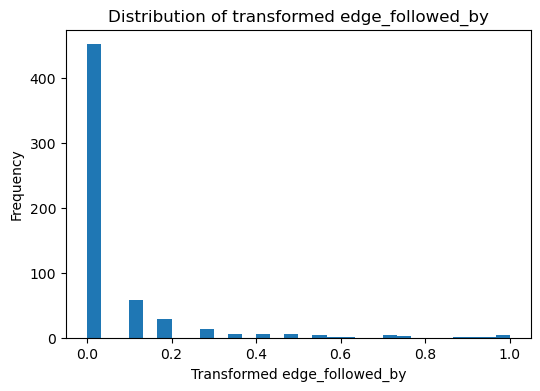

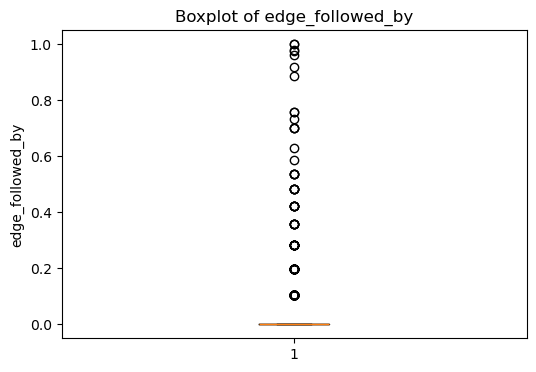

In [7]:
plot_hist_box(X_train_scaled, 'edge_followed_by')

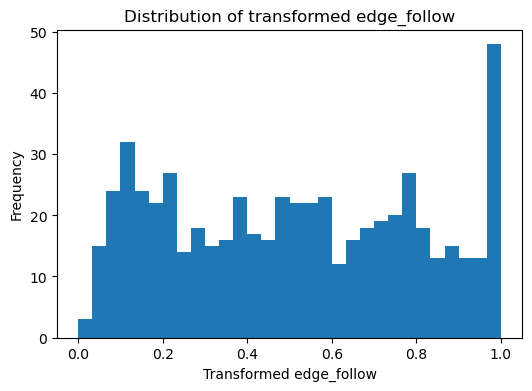

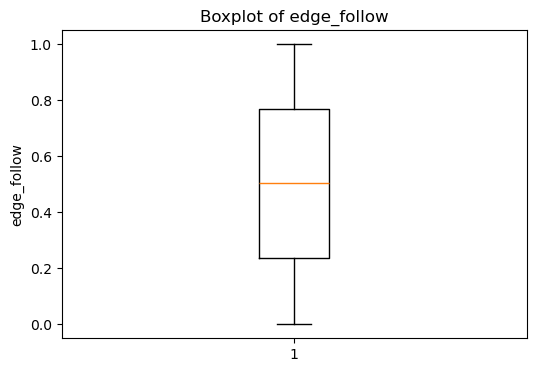

In [8]:
plot_hist_box(X_train_scaled, 'edge_follow')

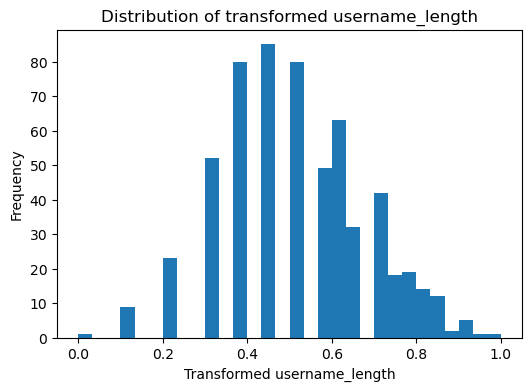

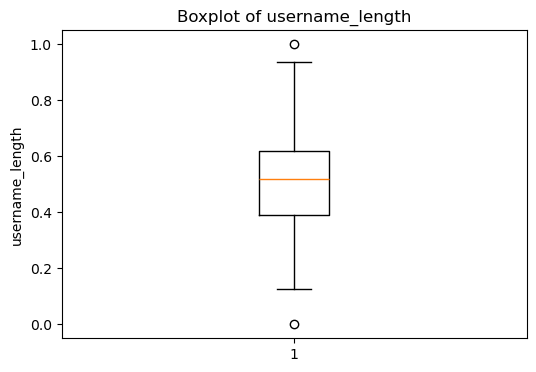

In [9]:
plot_hist_box(X_train_scaled, 'username_length')

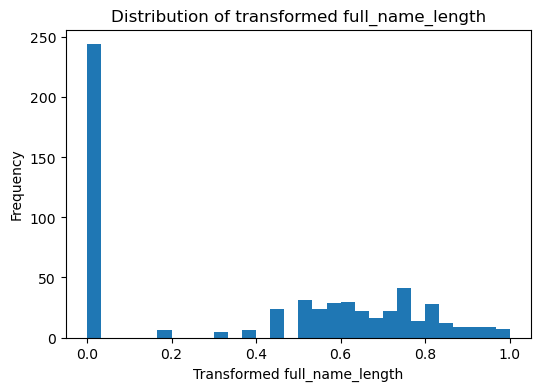

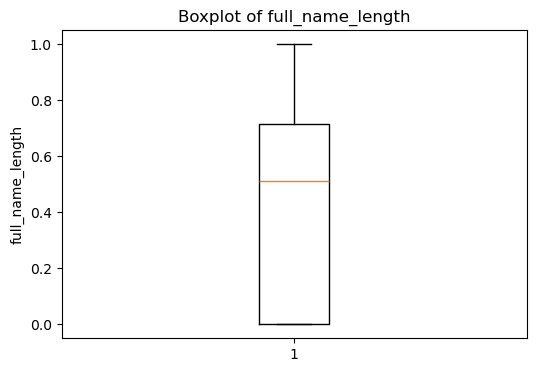

In [10]:
plot_hist_box(X_train_scaled, 'full_name_length')